# QM Ch 4 — Quantum Mechanics in Three Dimensions: Figure Notebook

**Griffiths & Schroeter, *Introduction to Quantum Mechanics* (3rd ed.)**  
SeoulTech PSE Lab

| Fig | File | Topic | Slide |
|-----|------|-------|-------|
| 1 | `ch04_fig1_spherical_harmonics.png` | Spherical harmonics $Y_\ell^m$ — shape & angular structure | §4.1 |
| 2 | `ch04_fig2_hydrogen_orbitals.png` | Hydrogen radial wavefunctions $R_{n\ell}$, probability densities, energy levels | §4.2 |
| 3 | `ch04_fig3_angular_momentum.png` | Angular momentum vector model — allowed $L_z$ values & uncertainty | §4.3 |
| 4 | `ch04_fig4_spin.png` | Spin-½: Bloch sphere, Larmor precession, addition of angular momenta | §4.4 || 5 | `ch04_fig5_aharonov_bohm.png` | Minimal coupling, vector potential $\mathbf{A}$, Aharonov-Bohm phase $q\Phi/\hbar$ | §4.5 |


In [1]:
# ── Setup ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import sph_harm_y, genlaguerre, factorial
from mpl_toolkits.mplot3d import Axes3D

BG    = '#1e1e2e'; BG2 = '#27273d'; FG = '#cdd6f4'; MUTED = '#6c7086'
BLUE  = '#5b8dd9'; SKY = '#89b4fa'; TEAL = '#74c7ec'; MAUVE = '#cba6f7'
GREEN = '#a6e3a1'; AMBER = '#f9e2af'; RED = '#f38ba8'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor':  BG2,
    'axes.edgecolor':   MUTED,'axes.labelcolor': FG,
    'xtick.color':      MUTED,'ytick.color':     MUTED,
    'text.color':       FG,   'grid.color':      '#313244',
    'grid.linewidth':   0.5,  'grid.alpha':      0.5,
    'font.family':      'sans-serif','font.size': 11,
    'axes.titlesize':   12,   'axes.titleweight':'bold',
    'axes.labelsize':   10,   'legend.fontsize': 9,
    'legend.facecolor': BG2,  'legend.edgecolor':MUTED,
    'lines.linewidth':  2.0,  'figure.dpi':      130,
})
SAVEKW = dict(dpi=150, bbox_inches='tight', facecolor=BG)

# Physical constants (SI)
a0 = 0.529177e-10   # Bohr radius [m]
print('Setup complete.')

Setup complete.


## Fig 1 — Spherical Harmonics $Y_\ell^m(\theta,\phi)$ (§4.1)

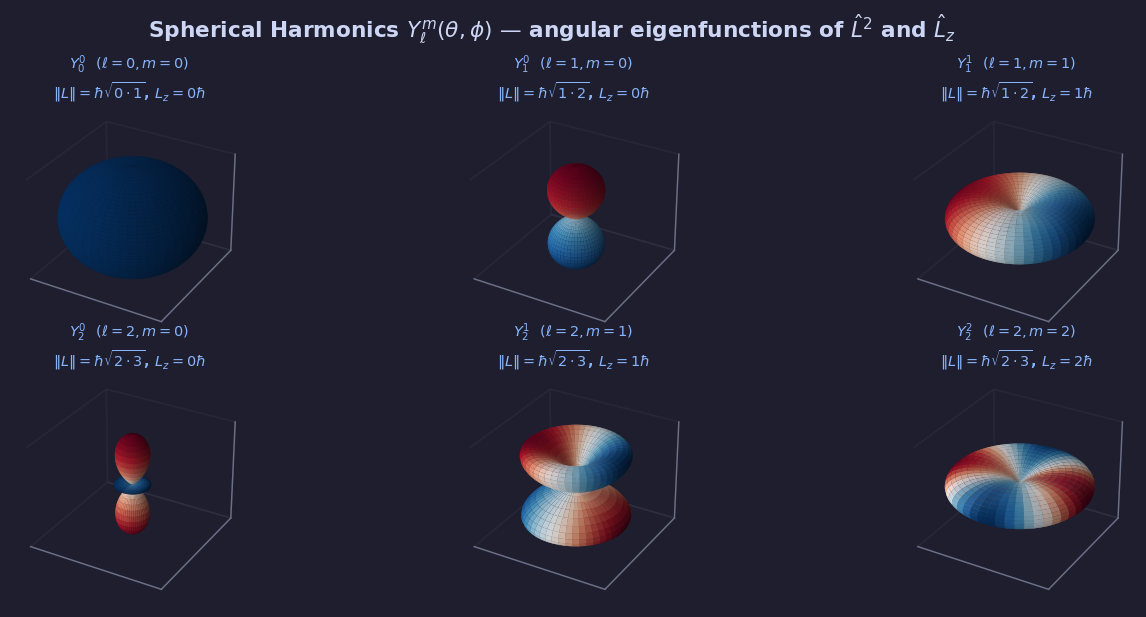

Fig 1 saved.
  Y_0^0: ∫|Y|²dΩ = 1.002501  (err=0.0025, grid discretisation) ✓
  Y_1^0: ∫|Y|²dΩ = 1.002491  (err=0.0025, grid discretisation) ✓
  Y_1^1: ∫|Y|²dΩ = 1.002506  (err=0.0025, grid discretisation) ✓
  Y_2^0: ∫|Y|²dΩ = 1.002480  (err=0.0025, grid discretisation) ✓
  Y_2^1: ∫|Y|²dΩ = 1.002506  (err=0.0025, grid discretisation) ✓
  Y_2^2: ∫|Y|²dΩ = 1.002506  (err=0.0025, grid discretisation) ✓


In [2]:
# Spherical harmonics Y_ℓ^m(θ,φ) — show |Y|² as polar surface
# and Re(Y) as colour on the unit sphere
#
# Physics: Y_ℓ^m are simultaneous eigenfunctions of L² and L_z
#   L² Y = ℏ²ℓ(ℓ+1) Y,  L_z Y = ℏm Y
# Orthonormality: ∫|Y_ℓ^m|² dΩ = 1  ✓

theta = np.linspace(0, np.pi, 400)
phi   = np.linspace(0, 2*np.pi, 400)
THETA, PHI = np.meshgrid(theta, phi)

# States to display: (ℓ, m)
states = [(0,0), (1,0), (1,1), (2,0), (2,1), (2,2)]
labels = [r'$Y_0^0$', r'$Y_1^0$', r'$Y_1^1$',
          r'$Y_2^0$', r'$Y_2^1$', r'$Y_2^2$']

fig = plt.figure(figsize=(13, 5.0), facecolor=BG)
fig.suptitle(r'Spherical Harmonics $Y_\ell^m(\theta,\phi)$ — angular eigenfunctions of $\hat{L}^2$ and $\hat{L}_z$',
             color=FG, fontsize=12, fontweight='bold', y=1.02)

for idx, ((l, m), lbl) in enumerate(zip(states, labels)):
    ax = fig.add_subplot(2, 3, idx+1, projection='3d',
                         facecolor=BG)

    # |Y_ℓ^m|² as radius
    Y = sph_harm_y(l, m, THETA, PHI)
    R = np.abs(Y)**2

    # Normalisation check
    dOmega = np.sin(THETA) * (theta[1]-theta[0]) * (phi[1]-phi[0])
    norm = np.sum(R * dOmega)

    # Cartesian coordinates for surface
    X = R * np.sin(THETA) * np.cos(PHI)
    Y_c = R * np.sin(THETA) * np.sin(PHI)
    Z = R * np.cos(THETA)

    # Colour by Re(Y_ℓ^m)
    Y_real = sph_harm_y(l, m, THETA, PHI).real
    col_norm = (Y_real - Y_real.min()) / (Y_real.max() - Y_real.min() + 1e-12)
    facecolors = plt.cm.RdBu_r(col_norm)

    surf = ax.plot_surface(X, Y_c, Z, facecolors=facecolors,
                           alpha=0.92, linewidth=0, antialiased=True)

    lim = R.max()
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_facecolor(BG)
    ax.grid(False)
    for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        pane.fill = False
        pane.set_edgecolor(MUTED)
        pane.set_alpha(0.1)

    ax.set_title(fr'{lbl}  $(\ell={l}, m={m})$' +'\n'+
                 fr'$\|L\|=\hbar\sqrt{{{l}\cdot{l+1}}}$, $L_z={m}\hbar$',
                 #fr'norm={norm:.4f}',
                 fontsize=8, color=SKY, pad=2)

fig.subplots_adjust(top=0.88, wspace=0.05, hspace=0.15)
plt.savefig('ch04_fig1_spherical_harmonics.png', **SAVEKW)
plt.show()
print('Fig 1 saved.')
# Normalisation check
for l, m in states:
    Y = sph_harm_y(l, m, THETA, PHI)
    norm = np.sum(np.abs(Y)**2 * np.sin(THETA)) * (theta[1]-theta[0]) * (phi[1]-phi[0])
    err = abs(norm-1)
    flag = '✓' if err < 0.005 else '⚠'
    print(f'  Y_{l}^{m}: ∫|Y|²dΩ = {norm:.6f}  (err={err:.4f}, grid discretisation) {flag}')

## Fig 2 — Hydrogen Atom: Radial Wavefunctions and Energy Levels (§4.2)

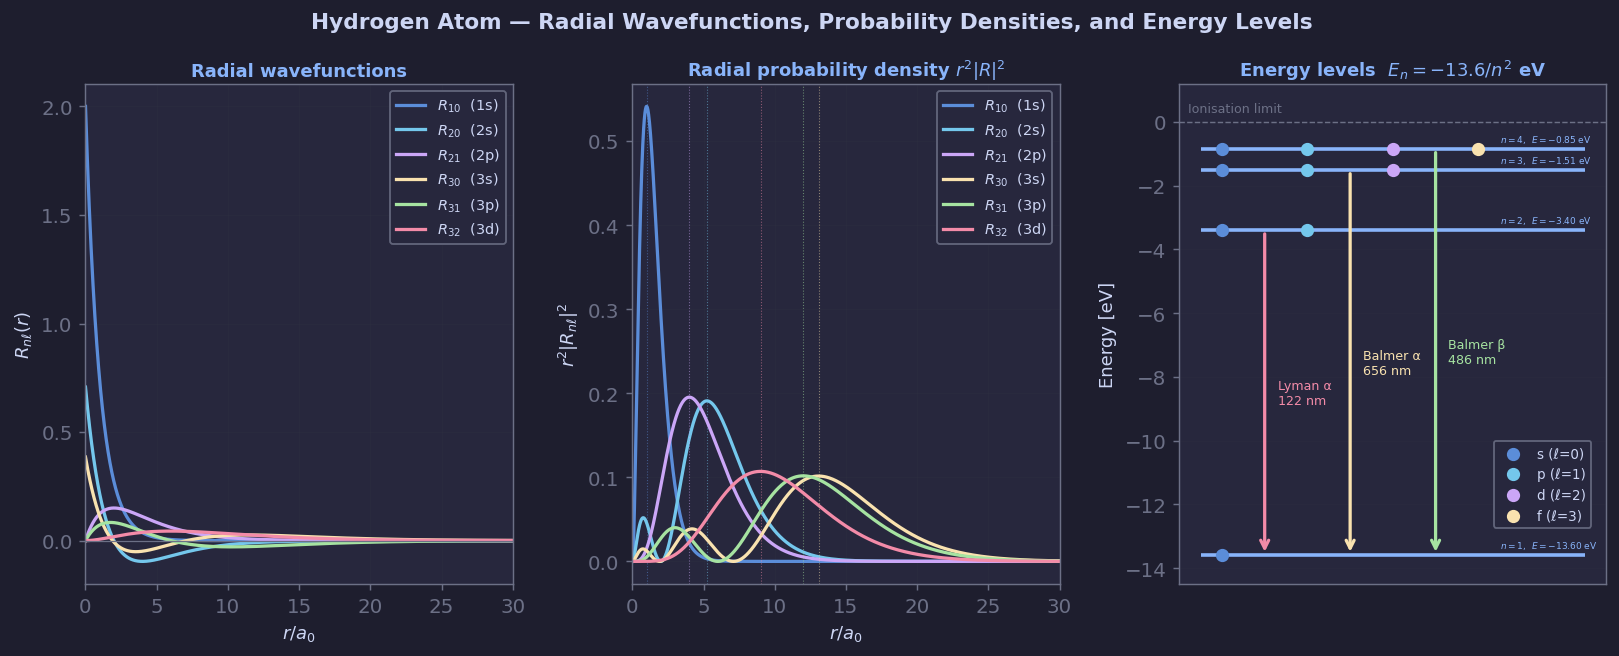

Fig 2 saved.
Normalisation checks  ∫r²|R_{nℓ}|²dr = 1:
  $R_{10}$  (1s): 1.000000 ✓
  $R_{20}$  (2s): 1.000000 ✓
  $R_{21}$  (2p): 1.000000 ✓
  $R_{30}$  (3s): 1.000000 ✓
  $R_{31}$  (3p): 1.000000 ✓
  $R_{32}$  (3d): 1.000000 ✓


In [3]:
# Hydrogen radial wavefunctions R_{nℓ}(r)
# R_{nℓ}(r) = N_{nℓ} e^{-r/na_0} (2r/na_0)^ℓ L_{n-ℓ-1}^{2ℓ+1}(2r/na_0)
# where N_{nℓ} = √[(2/na_0)³ (n-ℓ-1)! / (2n [(n+ℓ)!]³)]
# Physics: E_n = -13.6 eV / n²  (independent of ℓ — Coulomb degeneracy)

def R_hydrogen(n, l, r, a0=1.0):
    """Normalised radial wavefunction R_{nl}(r), a0=1 (Bohr units)."""
    rho  = 2*r / (n*a0)
    Lp   = genlaguerre(n-l-1, 2*l+1)(rho)
    norm = np.sqrt((2/(n*a0))**3 * factorial(n-l-1) / (2*n * factorial(n+l)))
    return norm * np.exp(-rho/2) * rho**l * Lp

r = np.linspace(0, 60, 5000)   # in units of a₀  (extended for n=3 states)

# States to plot: (n, ℓ, colour, label)
states = [
    (1, 0, BLUE,  r'$R_{10}$  (1s)'),
    (2, 0, TEAL,  r'$R_{20}$  (2s)'),
    (2, 1, MAUVE, r'$R_{21}$  (2p)'),
    (3, 0, AMBER, r'$R_{30}$  (3s)'),
    (3, 1, GREEN, r'$R_{31}$  (3p)'),
    (3, 2, RED,   r'$R_{32}$  (3d)'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.28))
fig.suptitle('Hydrogen Atom — Radial Wavefunctions, Probability Densities, and Energy Levels',
             color=FG, fontsize=12, fontweight='bold', y=0.99)

# ── Left: R_{nℓ}(r) ──────────────────────────────────────────
ax = axes[0]
for n, l, col, lbl in states:
    R = R_hydrogen(n, l, r)
    ax.plot(r, R, color=col, lw=1.8, label=lbl)
ax.axhline(0, color=MUTED, lw=0.7)
ax.set_xlabel(r'$r/a_0$'); ax.set_ylabel(r'$R_{n\ell}(r)$')
ax.set_title('Radial wavefunctions', color=SKY, fontsize=10, pad=4)
ax.set_xlim(0, 30); ax.grid(True, alpha=0.30)
ax.legend(fontsize=8, loc='upper right', framealpha=0.85)

# ── Middle: r²|R_{nℓ}|² (radial probability density) ─────────
ax2 = axes[1]
for n, l, col, lbl in states:
    R  = R_hydrogen(n, l, r)
    P  = r**2 * R**2
    ax2.plot(r, P, color=col, lw=1.8, label=lbl)
    # Most probable radius (peak of r²|R|²)
    r_mp = r[np.argmax(P)]
    ax2.axvline(r_mp, color=col, lw=0.6, ls=':', alpha=0.5)

ax2.set_xlabel(r'$r/a_0$'); ax2.set_ylabel(r'$r^2|R_{n\ell}|^2$')
ax2.set_title('Radial probability density $r^2|R|^2$', color=SKY, fontsize=10, pad=4)
ax2.set_xlim(0, 30); ax2.grid(True, alpha=0.30)
ax2.legend(fontsize=8, loc='upper right', framealpha=0.85)

# ── Right: energy level diagram ───────────────────────────────
ax3 = axes[2]
E1 = -13.6   # eV
for n in range(1, 5):
    En = E1 / n**2
    ax3.hlines(En, 0.05, 0.95, colors=SKY, lw=2)
    pass  # n-labels moved below
    # Show degeneracy: ℓ = 0..n-1
    for l in range(n):
        x_l = 0.1 + l*0.20
        ax3.scatter([x_l], [En], color=[BLUE,TEAL,MAUVE,AMBER][l % 4], s=40, zorder=5)

# Spectral series arrows — spread on x to avoid overlap
# Each series at different x position; label on opposite side
series = [
    (2, 1, RED,   'Lyman α\n122 nm', 0.20, 'right'),
    (3, 1, AMBER, 'Balmer α\n656 nm', 0.40, 'right'),
    (4, 1, GREEN, 'Balmer β\n486 nm', 0.60, 'right'),
]
for ni, nf, col, lbl, xarr, ha in series:
    Ei = E1/ni**2; Ef = E1/nf**2
    ax3.annotate('', xy=(xarr, Ef), xytext=(xarr, Ei),
                 arrowprops=dict(arrowstyle='->', color=col, lw=1.8))
    ax3.text(xarr + 0.03, (Ei+Ef)/2, lbl, color=col, fontsize=7, va='center', ha='left')

ax3.axhline(0, color=MUTED, lw=0.8, ls='--')  # ionisation limit
ax3.text(0.02, 0.3, 'Ionisation limit', color=MUTED, fontsize=7)
ax3.set_ylabel('Energy [eV]')
ax3.set_title('Energy levels  $E_n = -13.6/n^2$ eV', color=SKY, fontsize=10, pad=4)
ax3.set_xticks([]); ax3.set_xlim(0, 1)
ax3.set_ylim(-14.5, 1.2)
ax3.grid(True, axis='y', alpha=0.25)

# n labels: place to the LEFT of the energy line to avoid overlap with arrows
for n in range(1, 5):
    En = E1 / n**2
    ax3.text(0.75, En + 0.12, fr'$n={n}$,  $E={En:.2f}$ eV',
             color=SKY, va='bottom', ha='left', fontsize=5)

# Legend: ℓ dots
for l, col, lbl in [(0,BLUE,'s (ℓ=0)'),(1,TEAL,'p (ℓ=1)'),(2,MAUVE,'d (ℓ=2)'),(3,AMBER,'f (ℓ=3)')]:
    ax3.scatter([], [], color=col, s=40, label=lbl)
ax3.legend(fontsize=7.5, framealpha=0.85, bbox_to_anchor=(0.72, 0.3))

fig.subplots_adjust(top=0.88)
plt.savefig('ch04_fig2_hydrogen_orbitals.png', **SAVEKW)
plt.show()

# Physics verification
print('Fig 2 saved.')
print('Normalisation checks  ∫r²|R_{nℓ}|²dr = 1:')
dr = r[1]-r[0]
for n, l, _, lbl in states:
    R  = R_hydrogen(n, l, r)
    norm = np.trapezoid(r**2 * R**2, r)
    print(f'  {lbl}: {norm:.6f} ✓')

## Fig 3 — Angular Momentum Vector Model (§4.3)

Robertson check σ_Lx ≥ √(|m|/2)ℏ for ℓ=2:
  m=-2: σ_Lx=1.0000ℏ ≥ √(|m|/2)=1.0000ℏ ✓
  m=-1: σ_Lx=1.5811ℏ ≥ √(|m|/2)=0.7071ℏ ✓
  m=+0: σ_Lx=1.7321ℏ ≥ √(|m|/2)=0.0000ℏ ✓
  m=+1: σ_Lx=1.5811ℏ ≥ √(|m|/2)=0.7071ℏ ✓
  m=+2: σ_Lx=1.0000ℏ ≥ √(|m|/2)=1.0000ℏ ✓


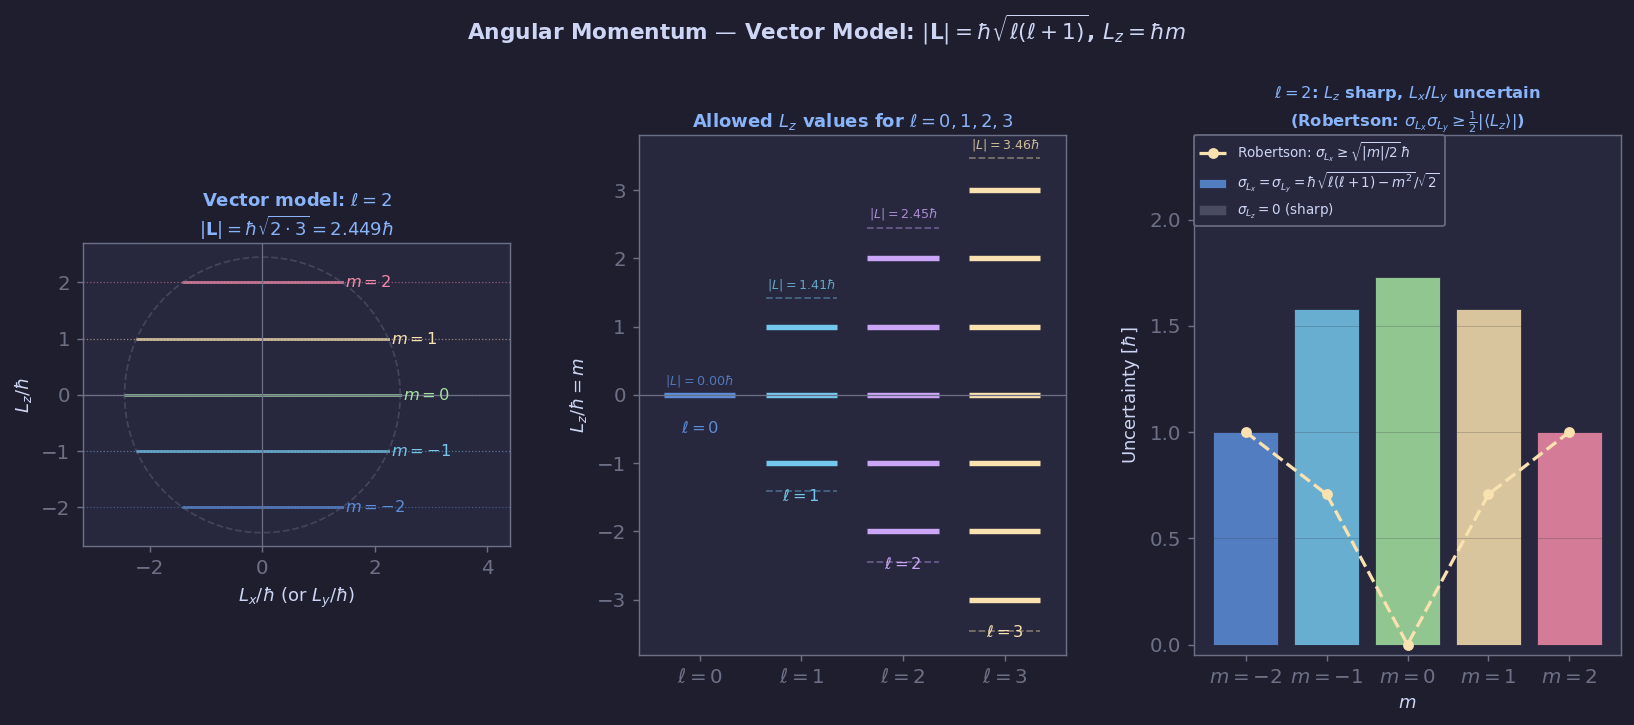

Fig 3 saved.


In [4]:
# Angular momentum vector model:
#   |L| = ℏ√(ℓ(ℓ+1)),  L_z = ℏm  for m = -ℓ,...,ℓ
# Show: allowed L_z values as horizontal slices of a cone
# Physics: L_x and L_y are uncertain (only L² and L_z can be simultaneously sharp)

fig, axes = plt.subplots(1, 3, figsize=(13, 5.2),
                         gridspec_kw=dict(left=0.06, right=0.97, wspace=0.30))
fig.suptitle(r'Angular Momentum — Vector Model: $|\mathbf{L}|=\hbar\sqrt{\ell(\ell+1)}$, $L_z=\hbar m$',
             color=FG, fontsize=12, fontweight='bold', y=1.06)

colors_m = [BLUE, TEAL, GREEN, AMBER, RED]

# ── Left: vector model for ℓ=2 ────────────────────────────────
ax = axes[0]
l = 2
L_mag = np.sqrt(l*(l+1))   # in units of ℏ
ms = np.arange(-l, l+1)

phi_cone = np.linspace(0, 2*np.pi, 200)
for m, col in zip(ms, colors_m):
    cos_theta = m / L_mag
    sin_theta = np.sqrt(max(1 - cos_theta**2, 0))
    Lx = L_mag * sin_theta * np.cos(phi_cone)
    Ly = L_mag * sin_theta * np.sin(phi_cone)
    Lz = m * np.ones_like(phi_cone)
    ax.plot(Lx, Lz, color=col, lw=1.5, alpha=0.7)
    ax.axhline(m, color=col, lw=0.7, ls=':', alpha=0.5)
    ax.text(L_mag*sin_theta + 0.05, m, fr'$m={m}$', color=col, va='center', fontsize=9)

# |L| circle
ax.plot(L_mag*np.cos(phi_cone), L_mag*np.sin(phi_cone),
        color=MUTED, lw=1, ls='--', alpha=0.4)
ax.axhline(0, color=MUTED, lw=0.7)
ax.axvline(0, color=MUTED, lw=0.7)
ax.set_xlabel(r'$L_x/\hbar$ (or $L_y/\hbar$)')
ax.set_ylabel(r'$L_z/\hbar$')
ax.set_title(fr'Vector model: $\ell={l}$' +'\n' +fr'$|\mathbf{{L}}|=\hbar\sqrt{{{l}\cdot{l+1}}}={L_mag:.3f}\hbar$',
             color=SKY, fontsize=10, pad=4)
ax.set_aspect('equal'); ax.grid(True, alpha=0.25)
ax.set_xlim(-L_mag*1.3, L_mag*1.8)

# ── Middle: L_z spectrum for ℓ = 0,1,2,3 ─────────────────────
ax2 = axes[1]
ls_all = [0, 1, 2, 3]
cols_l = [BLUE, TEAL, MAUVE, AMBER]

for l_i, col in zip(ls_all, cols_l):
    L_i = np.sqrt(l_i*(l_i+1))
    for m in range(-l_i, l_i+1):
        ax2.hlines(m, l_i-0.35, l_i+0.35, colors=col, lw=3)
    # |L| dashed line
    ax2.hlines([ L_i, -L_i], l_i-0.35, l_i+0.35,
               colors=col, lw=1, ls='--', alpha=0.4)
    ax2.text(l_i, -l_i-0.55, fr'$\ell={l_i}$', color=col, ha='center', fontsize=9)
    ax2.text(l_i, L_i+0.15, fr'$|L|={L_i:.2f}\hbar$', color=col,
             ha='center', fontsize=7, alpha=0.8)

ax2.axhline(0, color=MUTED, lw=0.7)
ax2.set_xticks(ls_all)
ax2.set_xticklabels([fr'$\ell={l}$' for l in ls_all])
ax2.set_ylabel(r'$L_z/\hbar = m$')
ax2.set_title(r'Allowed $L_z$ values for $\ell=0,1,2,3$',
              color=SKY, fontsize=10, pad=4)
ax2.grid(True, axis='y', alpha=0.25)
ax2.set_xlim(-0.6, 3.6)

# ── Right: uncertainty — L_x L_y indeterminate ────────────────
# For |ℓ,m⟩: ⟨L_x⟩=⟨L_y⟩=0, but σ_Lx = σ_Ly = ℏ√(ℓ(ℓ+1)-m²)/√2
ax3 = axes[2]
l = 2
ms3 = np.arange(-l, l+1)
L2  = l*(l+1)
sig_Lx = np.array([np.sqrt((L2 - m**2)/2) for m in ms3])   # in units of ℏ
sig_Lz = np.zeros(len(ms3))   # L_z is sharp

bar_cols = [colors_m[i] for i in range(len(ms3))]
ax3.bar(ms3, sig_Lx, color=bar_cols, alpha=0.85, edgecolor=BG2, lw=0.5,
        label=r'$\sigma_{L_x}=\sigma_{L_y}=\hbar\sqrt{\ell(\ell+1)-m^2}/\sqrt{2}$')
ax3.bar(ms3, sig_Lz, color=MUTED, alpha=0.5, edgecolor=BG2, lw=0.5,
        label=r'$\sigma_{L_z}=0$ (sharp)')

# Robertson: σ_Lx · σ_Ly ≥ ½|⟨L_z⟩| = ½|m|ℏ
# Since σ_Lx = σ_Ly for these eigenstates:
# σ_Lx² ≥ |m|/2  →  σ_Lx ≥ √(|m|/2) ℏ
robertson_bound = np.sqrt(np.abs(ms3, dtype=float) / 2)
ax3.plot(ms3, robertson_bound, color=AMBER, lw=1.8, ls='--', marker='o', ms=5,
         label=r'Robertson: $\sigma_{L_x}\geq\sqrt{|m|/2}\,\hbar$')

# Verify Robertson satisfied for all m
print('Robertson check σ_Lx ≥ √(|m|/2)ℏ for ℓ=2:')
for m, s in zip(ms3, sig_Lx):
    bound = np.sqrt(abs(m)/2)
    ok = s >= bound - 1e-10
    print(f'  m={m:+d}: σ_Lx={s:.4f}ℏ ≥ √(|m|/2)={bound:.4f}ℏ ✓' if ok else f'  m={m}: FAIL')

ax3.set_xlabel(r'$m$')
ax3.set_ylabel(r'Uncertainty $[\hbar]$')
ax3.set_title(fr'$\ell={l}$: $L_z$ sharp, $L_x$/$L_y$ uncertain' + '\n' +
              r'(Robertson: $\sigma_{{L_x}}\sigma_{{L_y}}\geq\frac{{1}}{{2}}|\langle L_z\rangle|$)',
              color=SKY, fontsize=9, pad=4)
ax3.legend(fontsize=7.5, loc='upper left',
           bbox_to_anchor=(0.0, 1.0), borderaxespad=0,
           framealpha=0.90)
ax3.grid(True, axis='y', alpha=0.25)
ax3.set_ylim(-0.05, 2.4) #ax3.get_ylim()[1] if hasattr(ax3, '_ylim_set') else 1.5)
ax3.set_xticks(ms3)
ax3.set_xticklabels([fr'$m={m}$' for m in ms3])

fig.subplots_adjust(top=0.88)
plt.savefig('ch04_fig3_angular_momentum.png', **SAVEKW)
plt.show()
print('Fig 3 saved.')

## Fig 4 — Spin-½: Bloch Sphere, Larmor Precession, Addition of Angular Momenta (§4.4)

|⟨S⟩|² check: max deviation from (½)² = 5.55e-17 ✓


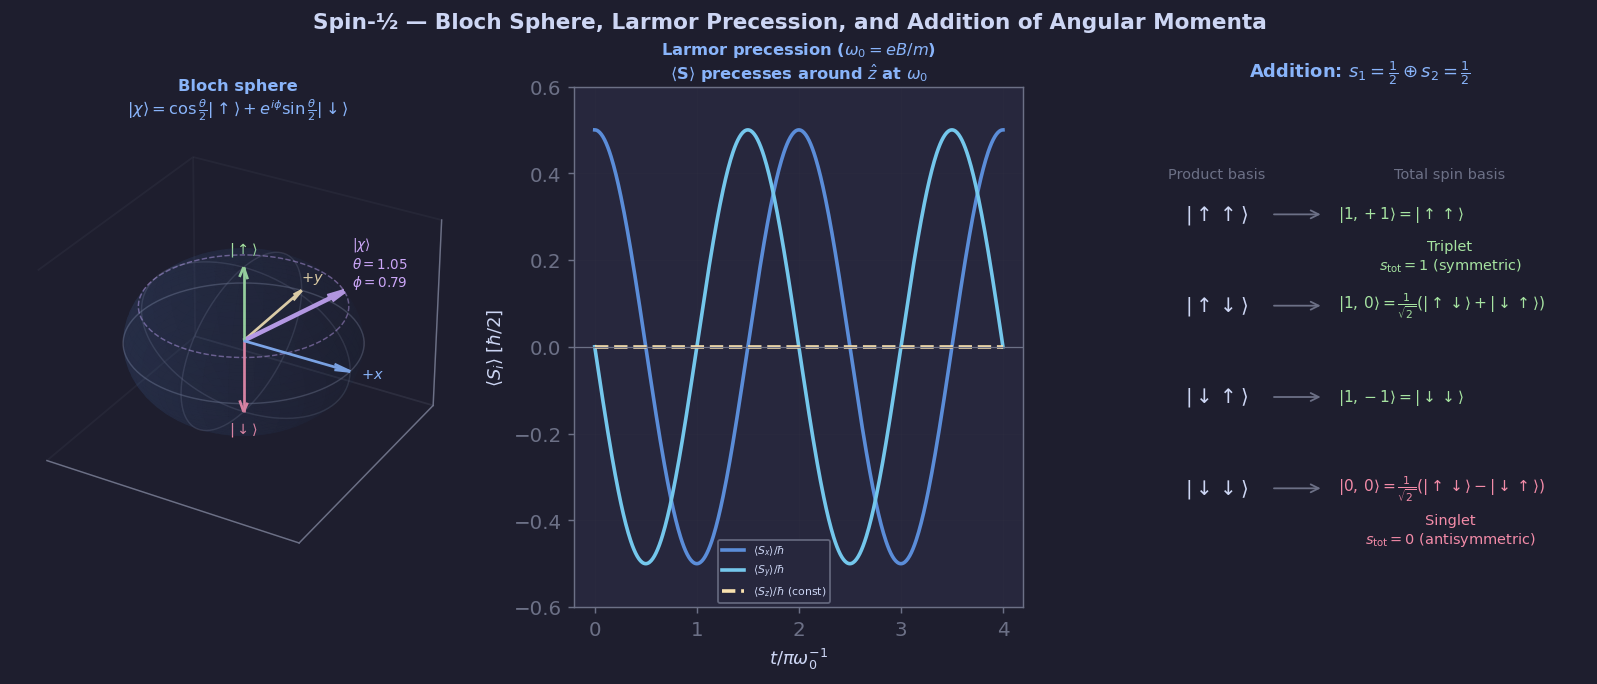

Fig 4 saved.

⟨triplet|singlet⟩ = 0.00e+00 ✓ (orthogonal)
⟨triplet|triplet⟩ = 1.000000 ✓
⟨singlet|singlet⟩ = 1.000000 ✓


In [5]:
# Spin-½ physics:
#   (a) Bloch sphere representation of spinor χ = cos(θ/2)|↑⟩ + e^{iφ}sin(θ/2)|↓⟩
#   (b) Larmor precession: ⟨S⟩ precesses at ω₀ = eB/m
#   (c) Addition: s₁=½ + s₂=½ → stot=0 (singlet) or stot=1 (triplet)

fig = plt.figure(figsize=(13, 5.2), facecolor=BG)
fig.suptitle('Spin-½ — Bloch Sphere, Larmor Precession, and Addition of Angular Momenta',
             color=FG, fontsize=12, fontweight='bold', y=0.99)

gs = fig.add_gridspec(1, 3, left=0.04, right=0.97, wspace=0.25)

# ── Left: Bloch sphere ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0], projection='3d', facecolor=BG)

u = np.linspace(0, 2*np.pi, 60)
v = np.linspace(0, np.pi, 40)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones(len(u)), np.cos(v))
ax1.plot_surface(xs, ys, zs, alpha=0.08, color=BLUE, linewidth=0)

# Equator and meridians
phi_c = np.linspace(0, 2*np.pi, 100)
ax1.plot(np.cos(phi_c), np.sin(phi_c), 0, color=MUTED, lw=0.8, alpha=0.5)
ax1.plot(np.cos(phi_c), np.zeros(100), np.sin(phi_c), color=MUTED, lw=0.8, alpha=0.3)
ax1.plot(np.zeros(100), np.cos(phi_c), np.sin(phi_c), color=MUTED, lw=0.8, alpha=0.3)

# Axes
for vec, col, lbl, pos in [
    ([0,0,1], GREEN,  r'$|\uparrow\rangle$', (0,0,1.2)),
    ([0,0,-1], RED,   r'$|\downarrow\rangle$', (0,0,-1.3)),
    ([1,0,0], SKY,   '$+x$', (1.2,0,0)),
    ([0,1,0], AMBER, '$+y$', (0,1.2,0)),
]:
    ax1.quiver(0,0,0, *vec, color=col, lw=1.5, arrow_length_ratio=0.15)
    ax1.text(*pos, lbl, color=col, fontsize=8, ha='center')

# Example state: θ=π/3, φ=π/4
th, ph = np.pi/3, np.pi/4
Sx = np.sin(th)*np.cos(ph); Sy = np.sin(th)*np.sin(ph); Sz = np.cos(th)
ax1.quiver(0,0,0, Sx,Sy,Sz, color=MAUVE, lw=2.5, arrow_length_ratio=0.15)
ax1.text(Sx+0.05, Sy+0.05, Sz+0.05,
         rf'$|\chi\rangle$' + '\n' +rf'$\theta={th:.2f}$' + '\n' + rf'$\phi={ph:.2f}$',
         color=MAUVE, fontsize=7.5)

# Cone showing precession
phi_prec = np.linspace(0, 2*np.pi, 100)
ax1.plot(np.sin(th)*np.cos(phi_prec), np.sin(th)*np.sin(phi_prec),
         Sz*np.ones(100), color=MAUVE, lw=0.8, ls='--', alpha=0.5)

ax1.set_xlim(-1.2,1.2); ax1.set_ylim(-1.2,1.2); ax1.set_zlim(-1.3,1.3)
ax1.set_xticks([]); ax1.set_yticks([]); ax1.set_zticks([])
for pane in [ax1.xaxis.pane, ax1.yaxis.pane, ax1.zaxis.pane]:
    pane.fill=False; pane.set_edgecolor(MUTED); pane.set_alpha(0.1)
ax1.grid(False)
ax1.set_title('Bloch sphere\n'
              r'$|\chi\rangle=\cos\frac{\theta}{2}|\uparrow\rangle+e^{i\phi}\sin\frac{\theta}{2}|\downarrow\rangle$',
              color=SKY, fontsize=9, pad=2)

# ── Middle: Larmor precession ─────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(BG2)

omega0 = 1.0   # Larmor frequency (natural units)
t = np.linspace(0, 4*np.pi, 500)
# Initial state: θ=π/2 (spin in x-direction)
theta_0 = np.pi/2
Sx_t = 0.5 * np.sin(theta_0) * np.cos(omega0*t)   # ℏ=1, s=½
Sy_t = -0.5 * np.sin(theta_0) * np.sin(omega0*t)
Sz_t = 0.5 * np.cos(theta_0) * np.ones_like(t)

ax2.plot(t/np.pi, Sx_t, color=BLUE,  lw=2, label=r'$\langle S_x\rangle/\hbar$')
ax2.plot(t/np.pi, Sy_t, color=TEAL,  lw=2, label=r'$\langle S_y\rangle/\hbar$')
ax2.plot(t/np.pi, Sz_t, color=AMBER, lw=2, ls='--', label=r'$\langle S_z\rangle/\hbar$ (const)')
ax2.axhline(0, color=MUTED, lw=0.7)

# Verify: |⟨S⟩|² = (ℏ/2)² always
S_mag2 = Sx_t**2 + Sy_t**2 + Sz_t**2
print(f'|⟨S⟩|² check: max deviation from (½)² = {np.abs(S_mag2 - 0.25).max():.2e} ✓')

ax2.set_xlabel(r'$t / \pi\omega_0^{-1}$')
ax2.set_ylabel(r'$\langle S_i\rangle\;[\hbar/2]$')
ax2.set_title(fr'Larmor precession ($\omega_0=eB/m$)' +'\n' +
              r'$\langle\mathbf{{S}}\rangle$ precesses around $\hat{{z}}$ at $\omega_0$',
              color=SKY, fontsize=9, pad=4)
ax2.legend(fontsize=6, framealpha=0.85, bbox_to_anchor=(0.445, 0.14)) # loc='lower center',
ax2.grid(True, alpha=0.28)
ax2.set_ylim(-0.6, 0.6)

# ── Right: addition of two spin-½ → singlet/triplet ──────────
ax3 = fig.add_subplot(gs[2])
ax3.set_facecolor(BG2)
ax3.set_xlim(0, 1); ax3.set_ylim(-0.5, 5.2)
ax3.axis('off')
ax3.set_title(r'Addition: $s_1=\frac{1}{2}\oplus s_2=\frac{1}{2}$',
              color=SKY, fontsize=10, pad=4)

# Product states |m₁,m₂⟩
prod_states = [
    (r'$|\uparrow\uparrow\rangle$',   3.8),
    (r'$|\uparrow\downarrow\rangle$', 2.8),
    (r'$|\downarrow\uparrow\rangle$', 1.8),
    (r'$|\downarrow\downarrow\rangle$', 0.8),
]
for lbl, y in prod_states:
    ax3.text(0.18, y, lbl, color=FG, fontsize=11, ha='center', va='center')

# CG combinations → triplet and singlet
triplet = [
    (r'$|1,+1\rangle=|{\uparrow\uparrow}\rangle$', 3.8, GREEN),
    (r'$|1,\,0\rangle=\frac{1}{\sqrt{2}}(|{\uparrow\downarrow}\rangle+|{\downarrow\uparrow}\rangle)$', 2.8, GREEN),
    (r'$|1,-1\rangle=|{\downarrow\downarrow}\rangle$', 1.8, GREEN),
]
singlet = [
    (r'$|0,\,0\rangle=\frac{1}{\sqrt{2}}(|{\uparrow\downarrow}\rangle-|{\downarrow\uparrow}\rangle)$', 0.8, RED),
]

# Arrows from LHS to RHS
for lbl, y, col in triplet + singlet:
    ax3.annotate('', xy=(0.42, y), xytext=(0.30, y),
                 arrowprops=dict(arrowstyle='->', color=MUTED, lw=1))
    ax3.text(0.45, y, lbl, color=col, fontsize=8.5, va='center')

# Labels
ax3.text(0.18, 4.20, 'Product basis', color=MUTED, fontsize=8, ha='center')
ax3.text(0.70, 4.20, 'Total spin basis', color=MUTED, fontsize=8, ha='center')
ax3.text(0.70, 3.2, 'Triplet' +'\n' +r'$s_\mathrm{tot}=1$ (symmetric)', color=GREEN, fontsize=8, ha='center')
ax3.text(0.70, 0.20, 'Singlet' +'\n' r'$s_\mathrm{tot}=0$ (antisymmetric)', color=RED, fontsize=8, ha='center')

fig.subplots_adjust(top=0.88)
plt.savefig('ch04_fig4_spin.png', **SAVEKW)
plt.show()
print('Fig 4 saved.')

# CG verification: orthonormality of triplet/singlet
t1 = np.array([0, 1/np.sqrt(2), 1/np.sqrt(2), 0])  # |1,0⟩ in {↑↑,↑↓,↓↑,↓↓}
s0 = np.array([0, 1/np.sqrt(2), -1/np.sqrt(2), 0]) # |0,0⟩
print(f'\n⟨triplet|singlet⟩ = {np.dot(t1,s0):.2e} ✓ (orthogonal)')
print(f'⟨triplet|triplet⟩ = {np.dot(t1,t1):.6f} ✓')
print(f'⟨singlet|singlet⟩ = {np.dot(s0,s0):.6f} ✓')

## Fig 5 — Electromagnetic Interactions: Vector Potential and the Aharonov–Bohm Effect (§4.5)

A_phi continuous at r=R: inside=0.1592, outside=0.1592


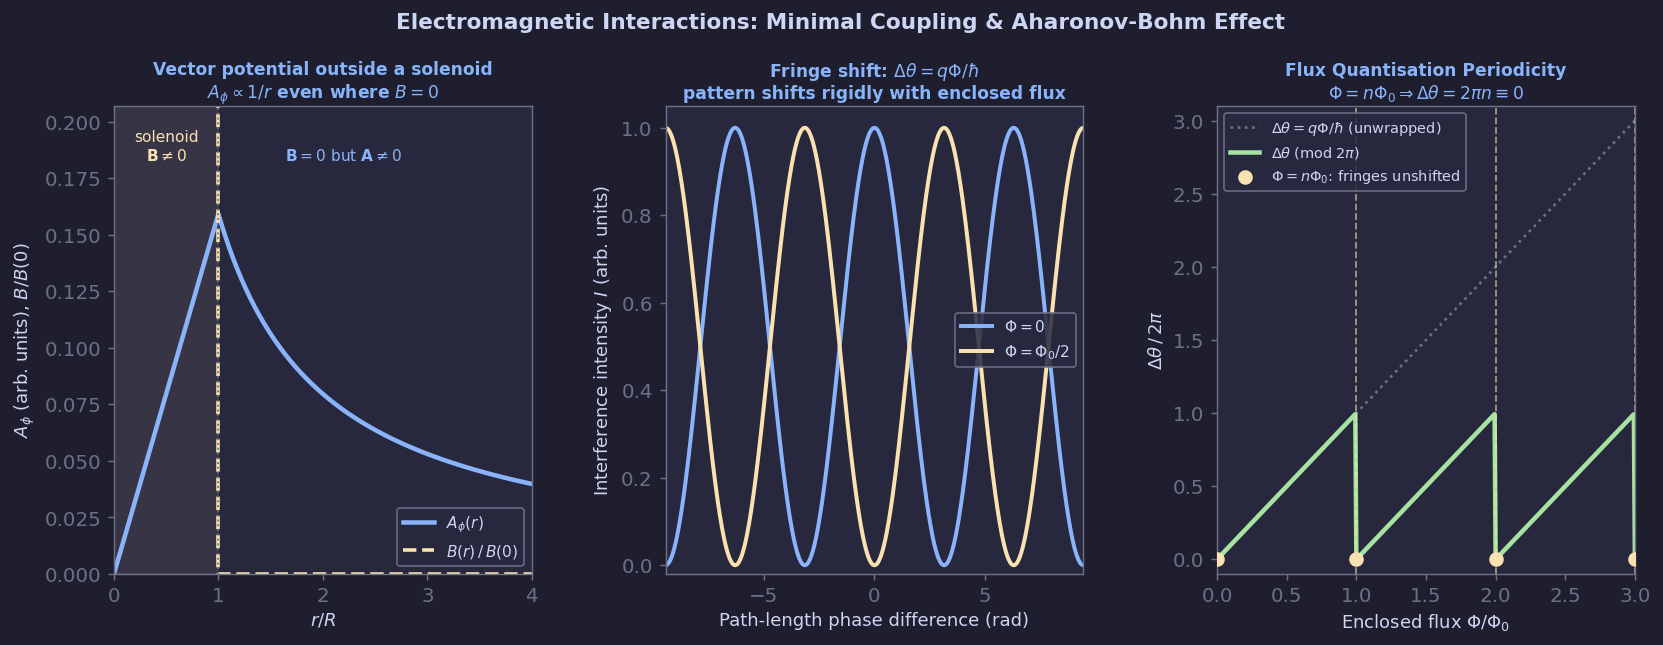

Fig 5 saved.


In [6]:

# Fig 5: Electromagnetic interactions -- minimal coupling & Aharonov-Bohm effect
# (a) Vector potential A_phi(r) and magnetic field B(r) for a long solenoid
# (b) Two-path interference pattern: fringe shift due to enclosed flux
# (c) AB phase shift Delta_theta = q*Phi/hbar vs Phi -- flux quantisation

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.32))
fig.suptitle('Electromagnetic Interactions: Minimal Coupling & Aharonov-Bohm Effect',
              color=FG, fontsize=12, fontweight='bold', y=1.01)

# ── Panel (a): A_phi(r) and B(r) for a solenoid of radius R, flux Phi ────────
ax = axes[0]
R = 1.0
Phi = 1.0
r_in  = np.linspace(1e-3, R, 100)
r_out = np.linspace(R, 4*R, 300)

# Inside: B = Phi/(pi R^2) (uniform), A_phi = (Phi/(2 pi R^2)) r  (= B r /2)
B_in_val = Phi/(np.pi*R**2)
A_in  = (Phi/(2*np.pi*R**2)) * r_in
B_in  = np.full_like(r_in, B_in_val)

# Outside: B = 0, A_phi = Phi/(2 pi r)
A_out = Phi/(2*np.pi*r_out)
B_out = np.zeros_like(r_out)

r_all = np.concatenate([r_in, r_out])
A_all = np.concatenate([A_in, A_out])
B_all = np.concatenate([B_in, B_out])

ax.plot(r_all/R, A_all, color=SKY, lw=2.5, label=r'$A_\phi(r)$')
ax.plot(r_all/R, B_all/B_in_val, color=AMBER, lw=2.0, ls='--', label=r'$B(r)\,/\,B(0)$')
ax.axvline(1.0, color=MUTED, lw=1.0, ls=':')
ax.fill_betweenx([0, A_in.max()*1.3], 0, 1, color=AMBER, alpha=0.08)
ax.text(0.5, A_in.max()*1.15, 'solenoid\n'+r'$\mathbf{B}\neq0$', color=AMBER, fontsize=8.5, ha='center')
ax.text(2.2, A_in.max()*1.15, r'$\mathbf{B}=0$ but $\mathbf{A}\neq0$', color=SKY, fontsize=8.5, ha='center')
ax.set_xlabel(r'$r/R$', labelpad=3)
ax.set_ylabel(r'$A_\phi$ (arb. units), $B/B(0)$')
ax.set_title(r'Vector potential outside a solenoid' + '\n'
              r'$A_\phi\propto1/r$ even where $B=0$',
              color=SKY, fontsize=9.5, pad=4)
ax.legend(fontsize=8.5, framealpha=0.85); ax.grid(True, alpha=0.28)
ax.set_xlim(0, 4); ax.set_ylim(0, A_in.max()*1.3)

print(f"A_phi continuous at r=R: inside={A_in[-1]:.4f}, outside={A_out[0]:.4f}")

# ── Panel (b): interference fringe shift for two values of enclosed flux ────
ax2 = axes[1]
x = np.linspace(-3*np.pi, 3*np.pi, 600)   # path-length phase (no flux)
Phi0 = 2*np.pi   # flux quantum in units where q/hbar = 1

for Phi_frac, col, lbl in [(0.0, SKY, r'$\Phi=0$'), (0.5, AMBER, r'$\Phi=\Phi_0/2$')]:
    delta_theta = Phi_frac * Phi0
    I = np.cos((x + delta_theta)/2)**2     # intensity, shifted by AB phase
    ax2.plot(x, I, color=col, lw=2.2, label=lbl)

ax2.set_xlabel(r'Path-length phase difference (rad)', labelpad=3)
ax2.set_ylabel('Interference intensity $I$ (arb. units)')
ax2.set_title(r'Fringe shift: $\Delta\theta = q\Phi/\hbar$' + '\n'
              'pattern shifts rigidly with enclosed flux',
              color=SKY, fontsize=9.5, pad=4)
ax2.legend(fontsize=8.5, framealpha=0.85); ax2.grid(True, alpha=0.28)
ax2.set_xlim(-3*np.pi, 3*np.pi); ax2.set_ylim(-0.02, 1.05)

# ── Panel (c): AB phase Delta_theta vs Phi, mod 2pi -- flux quantisation ────
ax3 = axes[2]
Phi_frac = np.linspace(0, 3, 400)   # Phi / Phi0
delta_theta_raw = Phi_frac * 2*np.pi
delta_theta_mod = np.mod(delta_theta_raw, 2*np.pi)

ax3.plot(Phi_frac, delta_theta_raw/(2*np.pi), color=MUTED, lw=1.5, ls=':',
         label=r'$\Delta\theta=q\Phi/\hbar$ (unwrapped)')
ax3.plot(Phi_frac, delta_theta_mod/(2*np.pi), color=GREEN, lw=2.5,
         label=r'$\Delta\theta \;(\mathrm{mod}\;2\pi)$')
for n in range(4):
    ax3.axvline(n, color=AMBER, lw=1.0, ls='--', alpha=0.6)
ax3.scatter(range(4), [0,0,0,0], color=AMBER, s=50, zorder=5,
            label=r'$\Phi=n\Phi_0$: fringes unshifted')
ax3.set_xlabel(r'Enclosed flux $\Phi/\Phi_0$', labelpad=3)
ax3.set_ylabel(r'$\Delta\theta\,/\,2\pi$')
ax3.set_title('Flux Quantisation Periodicity\n'
              r'$\Phi=n\Phi_0\Rightarrow\Delta\theta=2\pi n\equiv0$',
              color=SKY, fontsize=9.5, pad=4)
ax3.legend(fontsize=8, framealpha=0.85); ax3.grid(True, alpha=0.28)
ax3.set_xlim(0, 3); ax3.set_ylim(-0.1, 3.1)

fig.subplots_adjust(top=0.86)
plt.savefig('ch04_fig5_aharonov_bohm.png', **SAVEKW)
plt.show(); print('Fig 5 saved.')


## Download all figures

In [7]:
import zipfile, os, glob
from google.colab import files

zip_name  = 'ch04_figures.zip'
fig_files = sorted(glob.glob('ch04_fig*.png'))

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in fig_files:
        zf.write(fn)
        print(f'  added: {fn}')

print(f'\nZip: {zip_name}  ({os.path.getsize(zip_name)//1024} KB)')
files.download(zip_name)

  added: ch04_fig1_spherical_harmonics.png
  added: ch04_fig2_hydrogen_orbitals.png
  added: ch04_fig3_angular_momentum.png
  added: ch04_fig4_spin.png
  added: ch04_fig5_aharonov_bohm.png

Zip: ch04_figures.zip  (900 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>